# Week 3: Unsupervised Learning and Clustering Analysis

## Adult Income Dataset

This notebook performs unsupervised learning on the cleaned Adult Income dataset.

The objective is to identify meaningful groups of individuals based on demographic, educational, work-related, and financial characteristics without using the income target as an input to the clustering algorithm.

The analysis will focus on:

- Data preparation for clustering
- Feature selection
- Feature scaling
- K-Means clustering
- Elbow Method
- Silhouette Score
- Cluster visualization
- Cluster profiling
- Interpretation of cluster characteristics
- Potential business and research implications

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("../data/processed/adult_cleaned.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (32537, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
print(df.columns.tolist())


['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


In [4]:
# Step 2: Select numerical features for clustering

clustering_features = [
    "age",
    "education-num",
    "hours-per-week",
    "capital-gain",
    "capital-loss"
]

X = df[clustering_features].copy()

print("Selected clustering features:")
print(clustering_features)

print("\nShape of clustering data:", X.shape)

X.head()

Selected clustering features:
['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']

Shape of clustering data: (32537, 5)


,age,education-num,hours-per-week,capital-gain,capital-loss
0,39,13,40,2174,0
1,50,13,13,0,0
2,38,9,40,0,0
3,53,7,40,0,0
4,28,13,40,0,0


In [5]:
# Step 3: Check for missing values

print("Missing values in clustering features:")
print(X.isnull().sum())

print("\nTotal missing values:", X.isnull().sum().sum())

Missing values in clustering features:
age               0
education-num     0
hours-per-week    0
capital-gain      0
capital-loss      0
dtype: int64

Total missing values: 0


In [6]:
# Step 4: Check data types

print("Data types of clustering features:")
print(X.dtypes)

Data types of clustering features:
age               int64
education-num     int64
hours-per-week    int64
capital-gain      int64
capital-loss      int64
dtype: object


In [7]:
# Step 5: Summary statistics

X.describe().round(2)

,age,education-num,hours-per-week,capital-gain,capital-loss
count,32537.00,32537.00,32537.00,32537.00,32537.00
mean,38.59,10.08,40.44,1078.44,87.37
std,13.64,2.57,12.35,7387.96,403.10
min,17.00,1.00,1.00,0.00,0.00
25%,28.00,9.00,40.00,0.00,0.00
50%,37.00,10.00,40.00,0.00,0.00
75%,48.00,12.00,45.00,0.00,0.00
max,90.00,16.00,99.00,99999.00,4356.00


In [8]:
# Step 6: Standardize features before clustering

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=clustering_features,
    index=X.index
)

print("Features standardized successfully!")

X_scaled.head()

Features standardized successfully!


,age,education-num,hours-per-week,capital-gain,capital-loss
0,0.030390,1.134777,-0.035664,0.148292,-0.216743
1,0.836973,1.134777,-2.222483,-0.145975,-0.216743
2,-0.042936,-0.420679,-0.035664,-0.145975,-0.216743
3,1.056950,-1.198407,-0.035664,-0.145975,-0.216743
4,-0.776193,1.134777,-0.035664,-0.145975,-0.216743


In [9]:
# Step 7: Verify standardized features

print("Means after scaling:")
print(X_scaled.mean().round(2))

print("\nStandard deviations after scaling:")
print(X_scaled.std().round(2))

Means after scaling:
age              -0.0
education-num     0.0
hours-per-week   -0.0
capital-gain      0.0
capital-loss      0.0
dtype: float64

Standard deviations after scaling:
age               1.0
education-num     1.0
hours-per-week    1.0
capital-gain      1.0
capital-loss      1.0
dtype: float64


In [10]:
# Step 8: Elbow Method

inertia_values = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

# Display the inertia values
for k, inertia in zip(range(2, 11), inertia_values):
    print(f"K = {k}: Inertia = {inertia:.2f}")

K = 2: Inertia = 130792.76
K = 3: Inertia = 108071.20
K = 4: Inertia = 79689.14
K = 5: Inertia = 63170.58
K = 6: Inertia = 54879.43
K = 7: Inertia = 47931.29
K = 8: Inertia = 42593.05
K = 9: Inertia = 38363.64
K = 10: Inertia = 35224.45


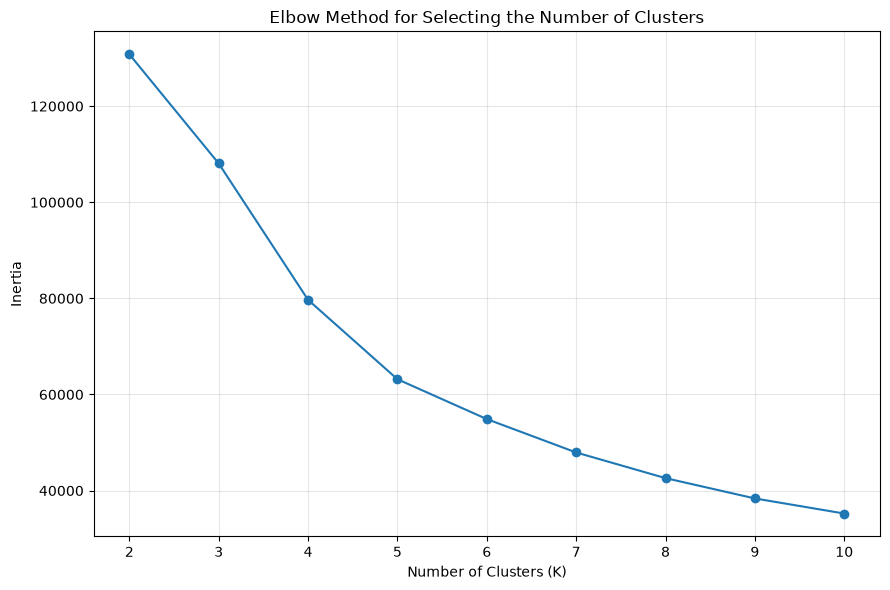

Elbow Method graph saved successfully!


In [11]:
# Step 9: Plot and save the Elbow Method

import os

os.makedirs("../screenshots/week3", exist_ok=True)

plt.figure(figsize=(9, 6))

plt.plot(
    range(2, 11),
    inertia_values,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Selecting the Number of Clusters")
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../screenshots/week3/elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Elbow Method graph saved successfully!")

In [12]:
# Step 10: Calculate Silhouette Scores

silhouette_values = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_values.append(score)

# Display the scores
for k, score in zip(range(2, 11), silhouette_values):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.5690
K = 3: Silhouette Score = 0.2453
K = 4: Silhouette Score = 0.2589
K = 5: Silhouette Score = 0.2934
K = 6: Silhouette Score = 0.3026
K = 7: Silhouette Score = 0.3178
K = 8: Silhouette Score = 0.3275
K = 9: Silhouette Score = 0.3286
K = 10: Silhouette Score = 0.3298


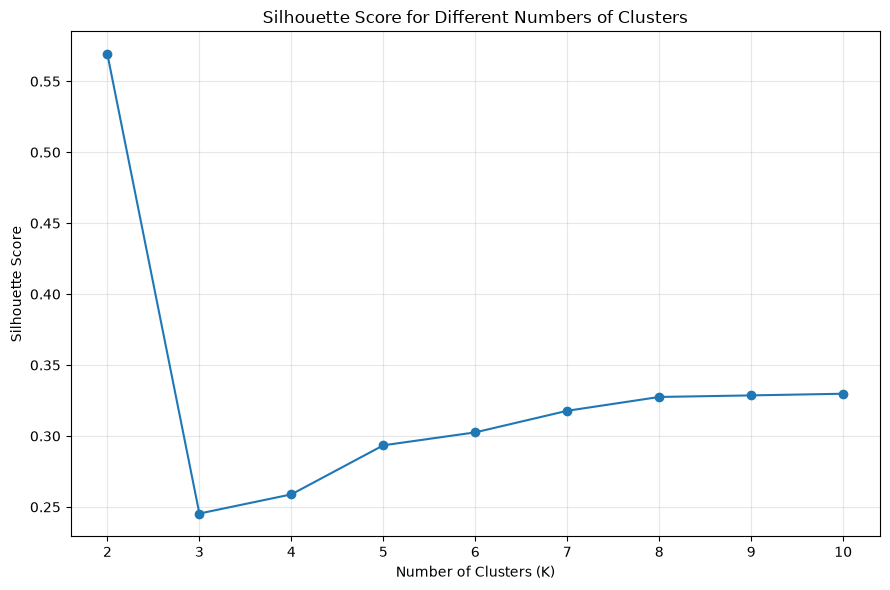

Silhouette Score graph saved successfully!


In [13]:
# Step 11: Plot and save Silhouette Scores

plt.figure(figsize=(9, 6))

plt.plot(
    range(2, 11),
    silhouette_values,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different Numbers of Clusters")
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../screenshots/week3/silhouette_scores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Silhouette Score graph saved successfully!")

In [14]:
# Step 12: Train the final K-Means model

final_k = 2

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to the original dataframe
df["cluster"] = cluster_labels

print("Final K-Means model trained successfully!")
print("Number of clusters:", final_k)

print("\nCluster sizes:")
print(df["cluster"].value_counts().sort_index())

Final K-Means model trained successfully!
Number of clusters: 2

Cluster sizes:
cluster
0     1484
1    31053
Name: count, dtype: int64


In [15]:
# Step 13: Calculate cluster percentages

cluster_counts = df["cluster"].value_counts().sort_index()

cluster_percentages = (
    cluster_counts / len(df) * 100
).round(2)

cluster_summary = pd.DataFrame({
    "Count": cluster_counts,
    "Percentage": cluster_percentages
})

cluster_summary

,Count,Percentage
cluster,,
0,1484,4.56
1,31053,95.44


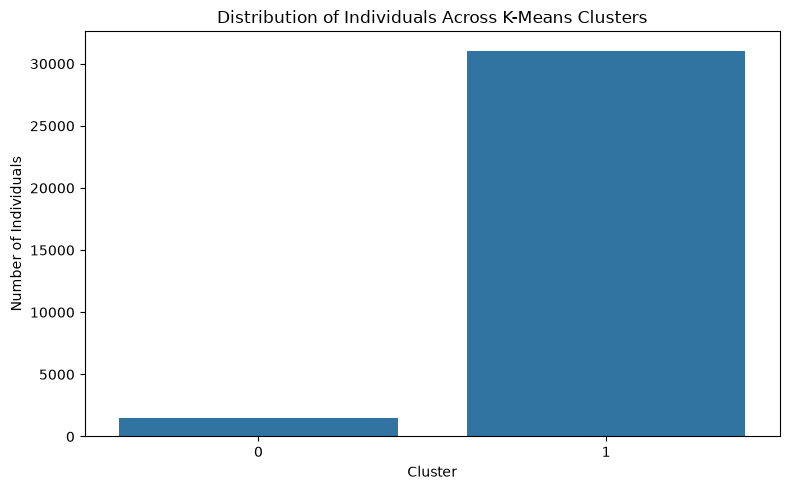

Cluster size graph saved successfully!


In [16]:
# Step 14: Visualize cluster sizes

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_summary.index,
    y=cluster_summary["Count"]
)

plt.xlabel("Cluster")
plt.ylabel("Number of Individuals")
plt.title("Distribution of Individuals Across K-Means Clusters")

plt.tight_layout()

plt.savefig(
    "../screenshots/week3/cluster_sizes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Cluster size graph saved successfully!")

## Cluster Size Distribution

The K-Means algorithm divided the dataset into two clusters based on age, education level, working hours, capital gain, and capital loss.

The cluster size distribution shows how the individuals are divided between Cluster 0 and Cluster 1. Examining the number and percentage of observations in each cluster helps determine whether the resulting groups are reasonably balanced or whether one cluster contains substantially more observations than the other.

The cluster counts and percentages are reported above to provide a concrete view of the distribution rather than relying only on the visualization.

This analysis provides the foundation for the next stage, where the characteristics of each cluster will be examined to understand what makes the groups different.

In [17]:
# Step 15: Profile the clusters

cluster_profile = df.groupby("cluster")[
    clustering_features
].mean().round(2)

cluster_profile

,age,education-num,hours-per-week,capital-gain,capital-loss
cluster,,,,,
0,41.63,10.99,43.36,0.00,1901.71
1,38.44,10.04,40.30,1129.98,0.66


In [18]:
# Step 16: Transpose cluster profile for easier interpretation

cluster_profile.T

cluster,0,1
age,41.63,38.44
education-num,10.99,10.04
hours-per-week,43.36,40.30
capital-gain,0.00,1129.98
capital-loss,1901.71,0.66


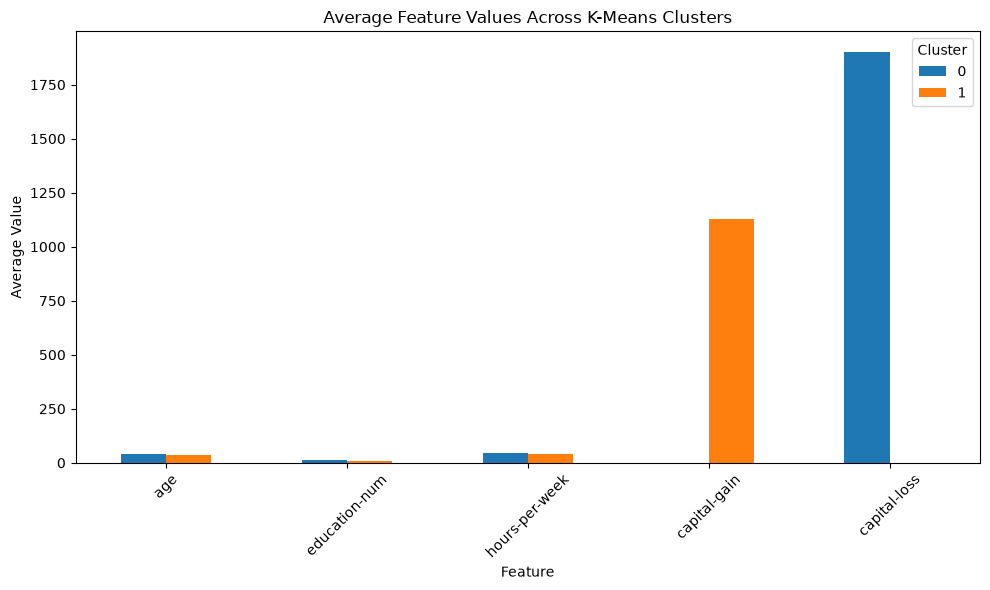

Cluster profile graph saved successfully!


In [19]:
# Step 17: Visualize cluster profiles

cluster_profile.T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Feature")
plt.ylabel("Average Value")
plt.title("Average Feature Values Across K-Means Clusters")
plt.xticks(rotation=45)
plt.legend(title="Cluster")

plt.tight_layout()

plt.savefig(
    "../screenshots/week3/cluster_profile.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Cluster profile graph saved successfully!")

## Cluster Profile Analysis

The cluster profile compares the average values of the selected numerical features across the two K-Means clusters.

The comparison includes age, education level, hours worked per week, capital gain, and capital loss. These averages help identify the main characteristics that distinguish one cluster from the other.

The visualization makes it easier to compare the clusters across the selected features. Differences in education, working hours, age, and financial variables provide useful information about the types of individuals represented by each group.

The cluster characteristics will be examined further using categorical variables such as workclass, occupation, marital status, and sex. This additional profiling will help provide a more complete interpretation of the clusters and their potential real-world implications.

In [20]:
# Step 18: Income distribution across clusters

income_cluster = pd.crosstab(
    df["cluster"],
    df["income"],
    normalize="index"
) * 100

income_cluster = income_cluster.round(2)

income_cluster

income,<=50K,>50K
cluster,,
0,48.05,51.95
1,77.24,22.76


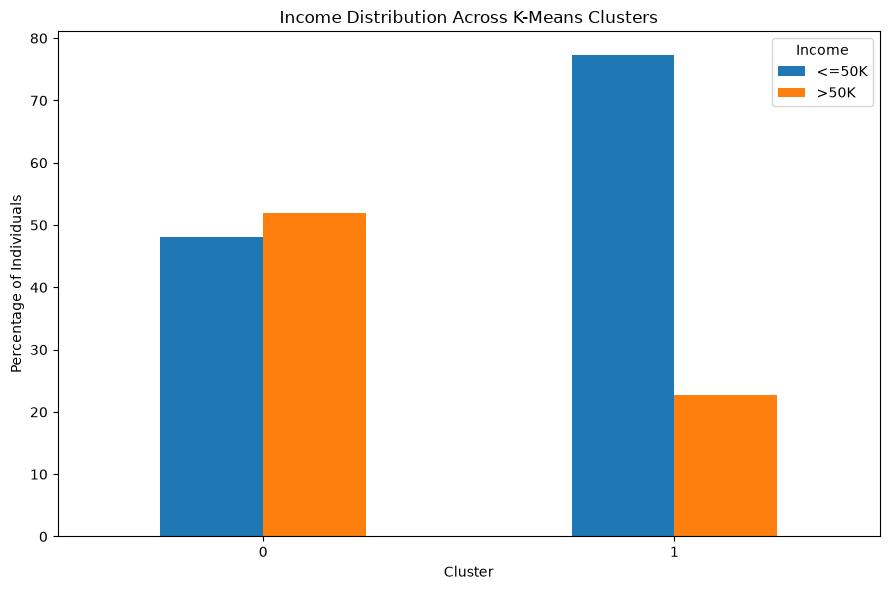

Income by cluster graph saved successfully!


In [21]:
# Step 19: Plot income distribution across clusters

income_cluster.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.xlabel("Cluster")
plt.ylabel("Percentage of Individuals")
plt.title("Income Distribution Across K-Means Clusters")
plt.xticks(rotation=0)
plt.legend(title="Income")

plt.tight_layout()

plt.savefig(
    "../screenshots/week3/income_by_cluster.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Income by cluster graph saved successfully!")

## Income Distribution Across Clusters

Although income was not used as an input feature during K-Means clustering, it can be examined after clustering to understand whether the resulting groups have different income distributions.

The visualization compares the percentage of individuals earning less than or equal to 50K with those earning more than 50K in each cluster.

This comparison helps evaluate whether the numerical characteristics used for clustering, such as education, age, working hours, and financial variables, are associated with different income patterns.

The results should be interpreted as an observed relationship within the clusters rather than as evidence that cluster membership directly causes a particular income level.

In [22]:
# Step 20: Workclass distribution within each cluster

workclass_cluster = pd.crosstab(
    df["cluster"],
    df["workclass"],
    normalize="index"
) * 100

workclass_cluster = workclass_cluster.round(2)

workclass_cluster

workclass,?,Federal-gov,Local-gov,Never-worked,Private,Self-emp-inc,Self-emp-not-inc,State-gov,Without-pay
cluster,,,,,,,,,
0,3.77,3.77,8.36,0.00,64.49,5.66,10.18,3.77,0.00
1,5.73,2.91,6.34,0.02,69.93,3.32,7.69,4.00,0.05


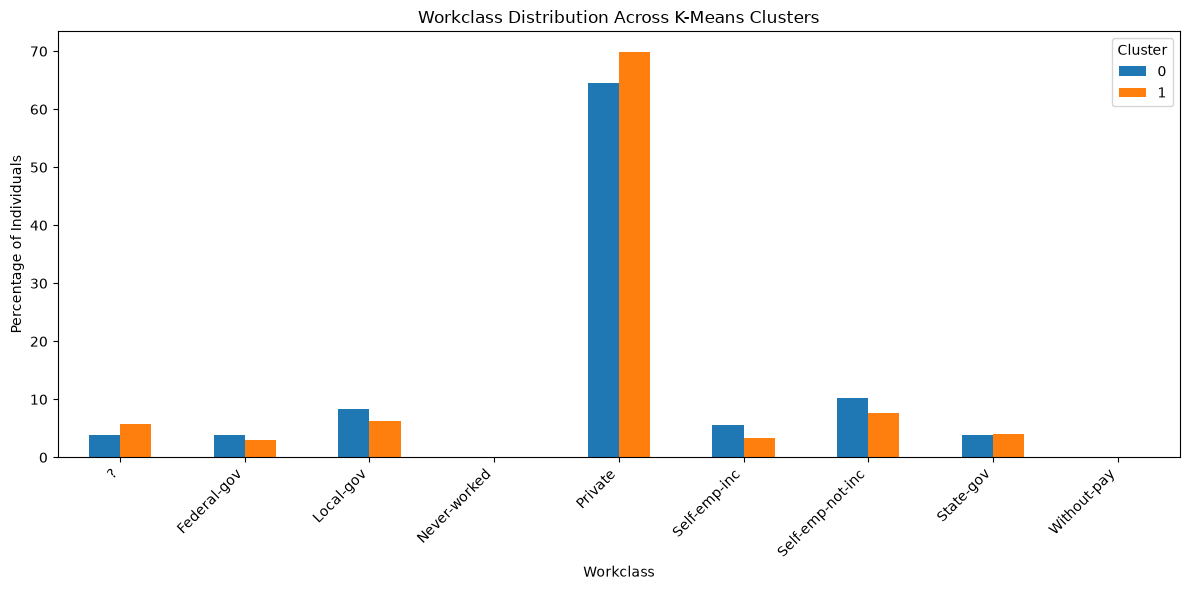

Workclass by cluster graph saved successfully!


In [23]:
# Step 21: Visualize workclass distribution across clusters

workclass_cluster.T.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Workclass")
plt.ylabel("Percentage of Individuals")
plt.title("Workclass Distribution Across K-Means Clusters")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Cluster")

plt.tight_layout()

plt.savefig(
    "../screenshots/week3/workclass_by_cluster.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Workclass by cluster graph saved successfully!")

## Workclass Distribution Across Clusters

The workclass distribution was examined to understand whether the two clusters differ in their employment categories.

The percentages show the composition of each cluster rather than the overall frequency of workclass categories. This makes it possible to compare the employment structure of Cluster 0 and Cluster 1 even when the clusters contain different numbers of individuals.

The differences observed in workclass composition provide additional context for understanding the types of individuals represented by each cluster. These patterns can be considered together with the numerical cluster profiles when interpreting the overall characteristics of the groups.

In [24]:
# Step 22: Occupation distribution within each cluster

occupation_cluster = pd.crosstab(
    df["cluster"],
    df["occupation"],
    normalize="index"
) * 100

occupation_cluster = occupation_cluster.round(2)

occupation_cluster

occupation,?,Adm-clerical,Armed-Forces,Craft-repair,Exec-managerial,Farming-fishing,Handlers-cleaners,Machine-op-inspct,Other-service,Priv-house-serv,Prof-specialty,Protective-serv,Sales,Tech-support,Transport-moving
cluster,,,,,,,,,,,,,,,
0,3.77,8.09,0.07,13.21,19.41,2.16,2.29,4.38,4.65,0.13,19.27,1.82,12.80,3.30,4.65
1,5.75,11.75,0.03,12.55,12.16,3.09,4.30,6.23,10.38,0.47,12.40,2.00,11.14,2.83,4.92


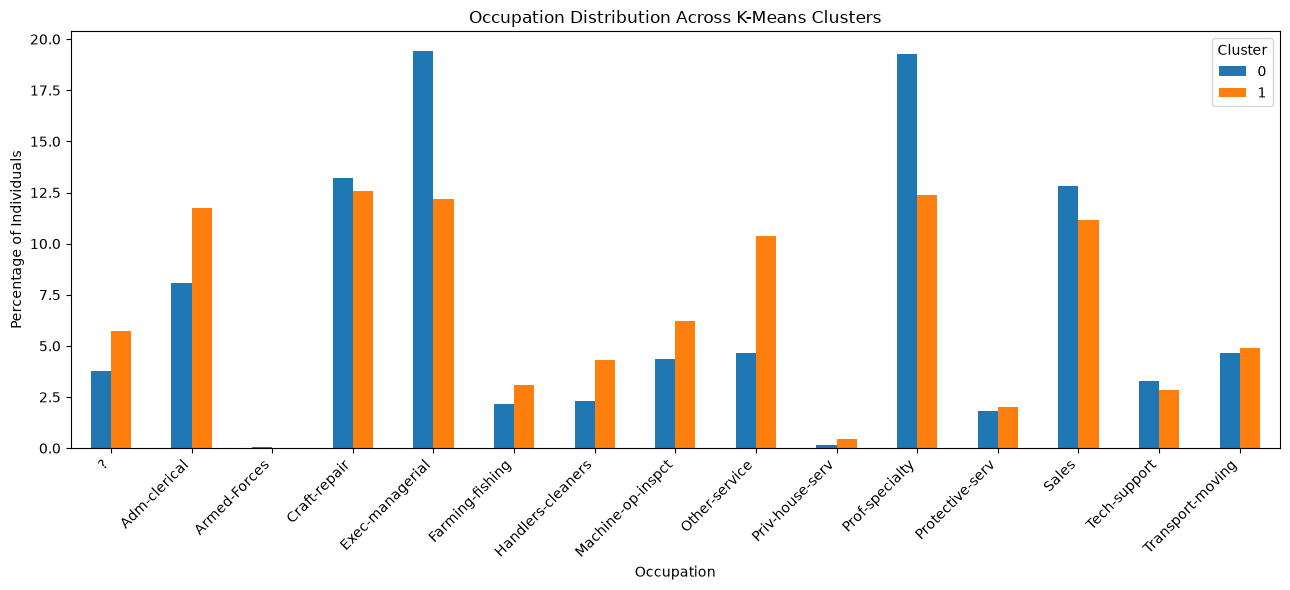

Occupation by cluster graph saved successfully!


In [25]:
# Step 22B: Visualize occupation distribution across clusters

occupation_cluster.T.plot(
    kind="bar",
    figsize=(13, 6)
)

plt.xlabel("Occupation")
plt.ylabel("Percentage of Individuals")
plt.title("Occupation Distribution Across K-Means Clusters")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Cluster")

plt.tight_layout()

plt.savefig(
    "../screenshots/week3/occupation_by_cluster.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Occupation by cluster graph saved successfully!")

## Occupation Distribution Across Clusters

Occupation provides another important way to interpret the clusters.

The distribution shows how different occupational categories are represented within Cluster 0 and Cluster 1. Comparing these percentages helps identify whether particular types of occupations are more common in one cluster than the other.

Occupation should be interpreted together with education, age, working hours, and financial variables because no single feature completely explains the differences between the clusters.

In [26]:
# Marital status distribution across clusters
marital_cluster = pd.crosstab(
    df["cluster"],
    df["marital-status"],
    normalize="index"
) * 100

marital_cluster.round(2)

marital-status,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Widowed
cluster,,,,,,,
0,9.70,0.00,64.35,0.94,20.89,1.75,2.36
1,13.84,0.07,45.13,1.30,33.35,3.22,3.09


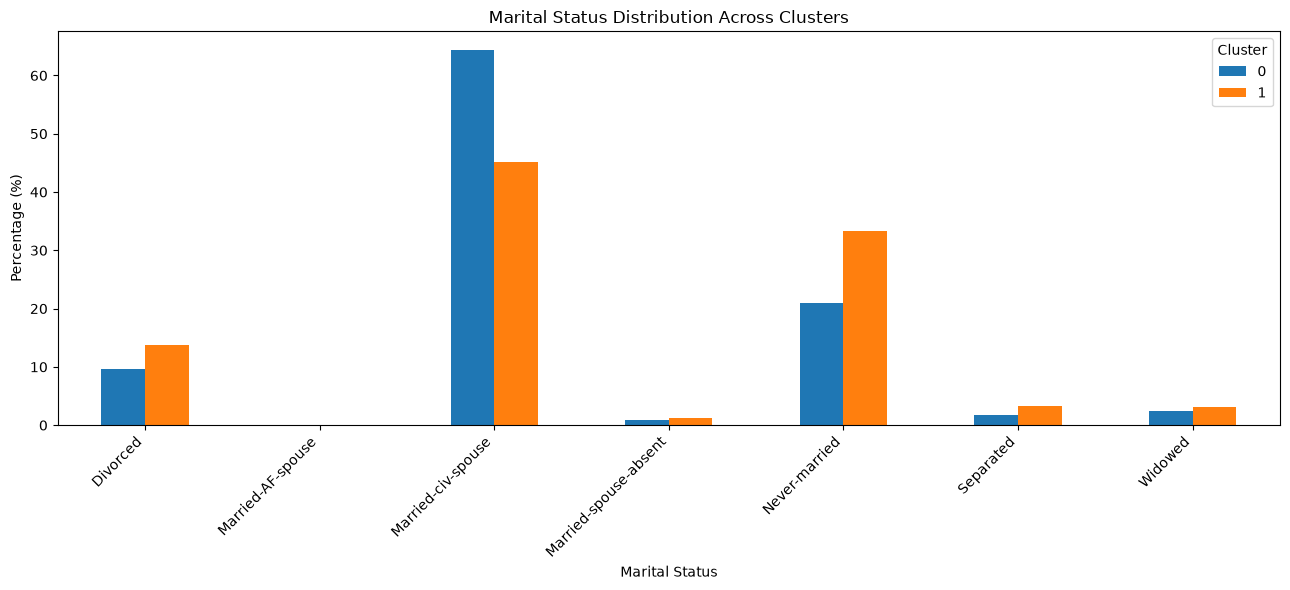

In [27]:
# Plot marital status distribution
ax = marital_cluster.T.plot(
    kind="bar",
    figsize=(13, 6)
)

plt.title("Marital Status Distribution Across Clusters")
plt.xlabel("Marital Status")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Cluster")
plt.tight_layout()

plt.savefig(
    "../screenshots/week3/marital_status_by_cluster.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Marital Status Distribution Across Clusters

Marital status was analyzed to further understand the demographic characteristics of the clusters.

The percentage distribution shows how different marital-status categories are represented within Cluster 0 and Cluster 1. Comparing these proportions helps identify whether the clusters have noticeably different demographic compositions.

These differences provide additional context for interpreting the clusters alongside the numerical features and occupational characteristics. However, marital status is used only for post-clustering interpretation and was not included as an input feature for K-Means.

In [28]:
# Sex distribution across clusters
sex_cluster = pd.crosstab(
    df["cluster"],
    df["sex"],
    normalize="index"
) * 100

sex_cluster.round(2)

sex,Female,Male
cluster,,
0,23.05,76.95
1,33.56,66.44


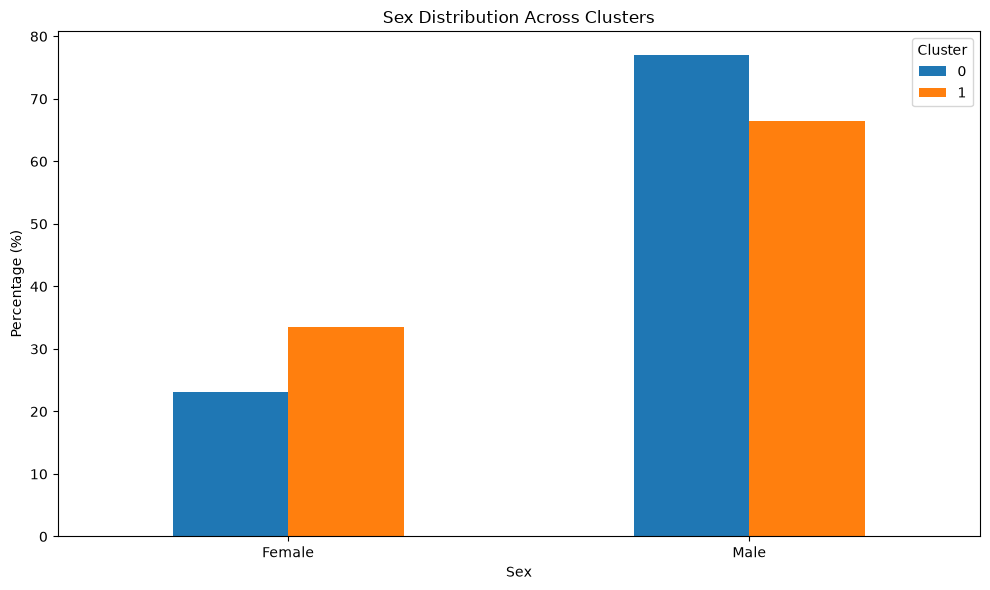

In [29]:
# Plot sex distribution
ax = sex_cluster.T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sex Distribution Across Clusters")
plt.xlabel("Sex")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Cluster")
plt.tight_layout()

plt.savefig(
    "../screenshots/week3/sex_by_cluster.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Sex Distribution Across Clusters

The sex distribution was examined to identify demographic differences between the two clusters.

The percentages show the proportion of male and female individuals within each cluster. Comparing these values helps determine whether the clusters have similar or different demographic compositions.

This analysis is useful for understanding the characteristics of the groups after clustering. Sex was not included as an input feature for K-Means, so these results are used only for post-clustering interpretation and should not be considered a factor that directly created the clusters.

In [30]:
# Apply PCA to reduce the clustering features to 2 dimensions
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["cluster"] = df["cluster"].values

print("Explained variance ratio:")
print(pca.explained_variance_ratio_.round(4))

print("\nTotal variance explained by PC1 and PC2:")
print(round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

Explained variance ratio:
[0.2593 0.206 ]

Total variance explained by PC1 and PC2:
46.54 %


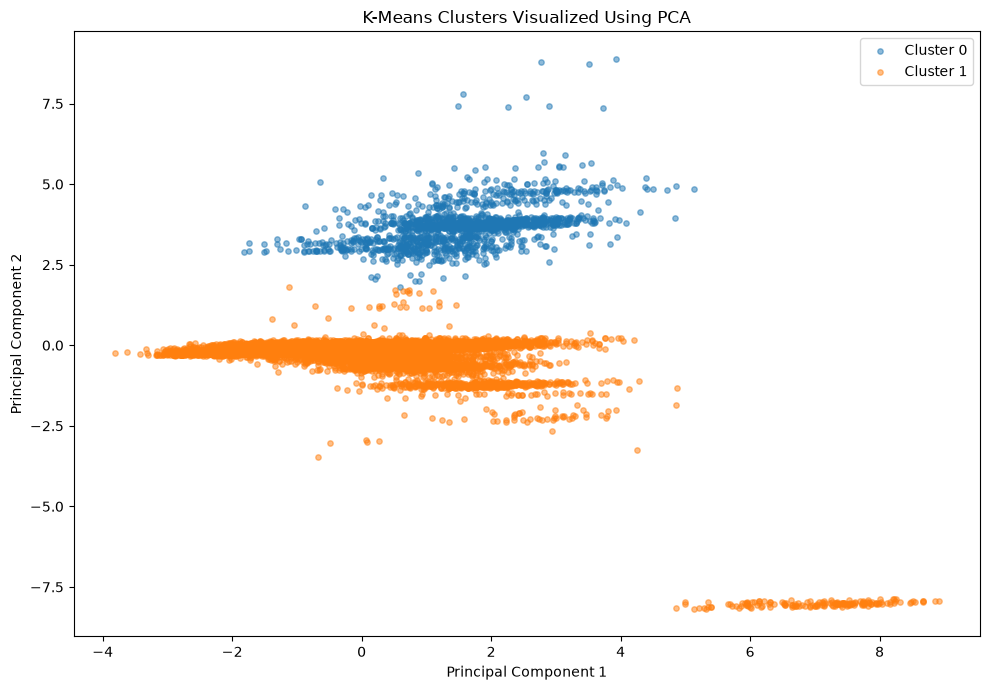

In [31]:
plt.figure(figsize=(10, 7))

for cluster in sorted(pca_df["cluster"].unique()):
    cluster_data = pca_df[pca_df["cluster"] == cluster]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.5,
        s=15
    )

plt.title("K-Means Clusters Visualized Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../screenshots/week3/pca_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## PCA-Based Cluster Visualization

Principal Component Analysis (PCA) was used to reduce the five-dimensional clustering data into two principal components for visualization.

The first two principal components provide a two-dimensional representation of the observations while retaining a portion of the variation present in the original features. The explained variance values printed above indicate how much of the original variation is represented by PC1 and PC2.

The scatter plot shows the observations according to their K-Means cluster assignments. The visualization provides a useful way to assess the degree of separation or overlap between Cluster 0 and Cluster 1.

Some overlap between the clusters is expected because the clustering was performed using five numerical features, while the visualization represents them in only two dimensions.

In [32]:
# Actual income counts within each cluster
income_counts = pd.crosstab(
    df["cluster"],
    df["income"]
)

income_counts

income,<=50K,>50K
cluster,,
0,713,771
1,23985,7068


In [33]:
# Income percentages within each cluster
income_percentages = pd.crosstab(
    df["cluster"],
    df["income"],
    normalize="index"
) * 100

income_percentages.round(2)

income,<=50K,>50K
cluster,,
0,48.05,51.95
1,77.24,22.76


## Income-Based Interpretation of the Clusters

Income was not used as an input feature during K-Means clustering. Instead, it was examined after clustering to determine whether the groups identified using numerical characteristics show different income patterns.

The table above provides both the actual number of individuals and the percentage distribution of income categories within each cluster.

Comparing the two clusters helps determine whether characteristics such as age, education level, working hours, capital gain, and capital loss are associated with different income distributions.

The results describe an observed relationship within this dataset and should not be interpreted as evidence that cluster membership causes a particular income level.

In [34]:
# Overall comparison of the two clusters
cluster_comparison = df.groupby("cluster")[clustering_features].agg(
    ["mean", "median"]
).round(2)

cluster_comparison

age        education-num        hours-per-week        capital-gain  \
          mean median          mean median           mean median         mean   
cluster                                                                         
0        41.63   41.0         10.99   10.0          43.36   40.0         0.00   
1        38.44   37.0         10.04   10.0          40.30   40.0      1129.98   

               capital-loss          
        median         mean  median  
cluster                              
0          0.0      1901.71  1887.0  
1          0.0         0.66     0.0

In [35]:
# Mean values for easier interpretation
cluster_mean_comparison = (
    df.groupby("cluster")[clustering_features]
    .mean()
    .round(2)
)

cluster_mean_comparison

,age,education-num,hours-per-week,capital-gain,capital-loss
cluster,,,,,
0,41.63,10.99,43.36,0.00,1901.71
1,38.44,10.04,40.30,1129.98,0.66


## Overall Cluster Comparison

The two clusters were compared using the mean and median values of the five numerical features used for K-Means clustering.

The comparison provides concrete numerical evidence of how Cluster 0 and Cluster 1 differ in terms of age, education level, working hours, capital gain, and capital loss.

Both mean and median values are considered because some financial variables can contain extreme values that may influence the mean. Comparing these statistics provides a more reliable understanding of the typical characteristics of each cluster.

These numerical differences, together with the categorical and income-based analyses, form the basis for the final interpretation of the clusters.

In [36]:
# Create a clear cluster characterization table
cluster_characteristics = df.groupby("cluster")[clustering_features].mean().round(2)

cluster_characteristics

,age,education-num,hours-per-week,capital-gain,capital-loss
cluster,,,,,
0,41.63,10.99,43.36,0.00,1901.71
1,38.44,10.04,40.30,1129.98,0.66


In [37]:
# Add cluster size
cluster_characteristics["count"] = df.groupby("cluster").size()

# Add percentage of individuals earning >50K
high_income_pct = (
    df.groupby("cluster")["income"]
    .apply(lambda x: (x == ">50K").mean() * 100)
    .round(2)
)

cluster_characteristics[">50K (%)"] = high_income_pct

cluster_characteristics

,age,education-num,hours-per-week,capital-gain,capital-loss,count,>50K (%)
cluster,,,,,,,
0,41.63,10.99,43.36,0.00,1901.71,1484,51.95
1,38.44,10.04,40.30,1129.98,0.66,31053,22.76


## Cluster Characterization

The final cluster characterization combines the numerical profiles with cluster size and the percentage of individuals earning more than 50K.

This table provides a concise summary of the differences between Cluster 0 and Cluster 1. The numerical features show how the groups differ in age, education level, working hours, capital gain, and capital loss, while the income percentage provides an additional post-clustering interpretation.

The combination of these measurements makes it possible to describe the overall characteristics of each cluster using concrete values rather than relying only on visual observations.

The cluster descriptions are based on patterns observed in this dataset and should not be treated as universal characteristics of all individuals.

In [38]:
# Save the final cluster characterization table
cluster_characteristics.to_csv(
    "../screenshots/week3/cluster_characteristics.csv"
)